# Tutorial 3 : Simulation strategy 2 on Lung cancer dataset

In [ ]:
#Restart runtime after every run
!git clone https://github.com/Zafar-Lab/spDDB.git

Cloning into 'spDDB'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (239/239), done.
remote: Compressing objects: 100% (191/191), done.
remote: Total 239 (delta 71), reused 203 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (239/239), 28.38 MiB | 19.13 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [ ]:
%cd spDDB/Experiments/_Binning_code_for_Gold_standard_datasets/
!ls

/content/spDDB/Experiments/_Binning_code_for_Gold_standard_datasets
Binning_in_python_brain.ipynb	       Binning_in_python_lung_cancer.ipynb
Binning_in_python_breast_cancer.ipynb  binning.py
Binning_in_python_ileum_100um.ipynb


Mounting google drive for accessing the input data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Installing Libraries

In [ ]:
!pip install scanpy
!pip install diptest

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 138.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.

Importing libraries

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest
from binning import *

In [ ]:
"""
We assume that the spot coordinates (avaiable with the datasets) are in um unit.
"""

'\nWe assume that the spot coordinates (avaiable with the datasets) are in um unit.\n'

In [ ]:
data_path = "/content/drive/MyDrive/Major_project/Benchmarking_Shared/spDDB_tutorials/3_data/"

unbinned_st_path = data_path + "unbinned_ST/ST_embeddings.h5ad"

binned_path = data_path + "ST_55_python.h5ad"

dataset =  "merfish_lung_cancer"
celltype_col = "celltype"
spot_diameter = 55 #55 # 550 -> 510 # 100->6, 9, etc.
coord1 = 0
coord2 = 1

combined_adata = binning(unbinned_st_path, spot_diameter, celltype_col, dataset, coord1, coord2)
print (combined_adata)

AnnData object with n_obs × n_vars = 13792 × 488
    obs: 'Monocytes1', 'Macrophages3', 'Macrophages1', 'Epithelial_cells', 'Macrophages2', 'Neutrophils_cells', 'Dendritic_cells', 'Stromal_cells', 'B_cells', 'T_cells', 'Endothelial_cells', 'NK_cells', 'Monocytes2', 'dataset'
    obsm: 'spatial'


Unbinned dataset

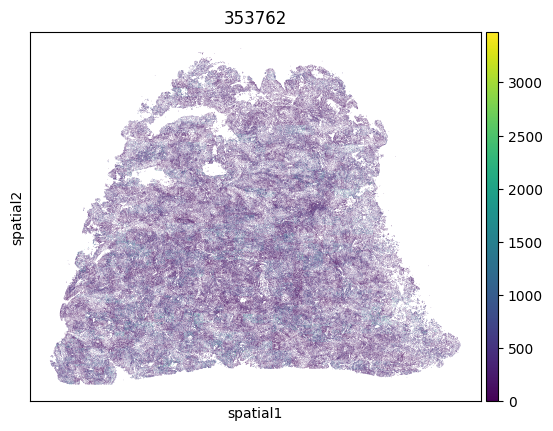

In [ ]:
st_adata = sc.read_h5ad(unbinned_st_path)
st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
sc.pl.embedding(st_adata, basis = "spatial", color = "umi_count", title = st_adata.shape)

Binned dataset

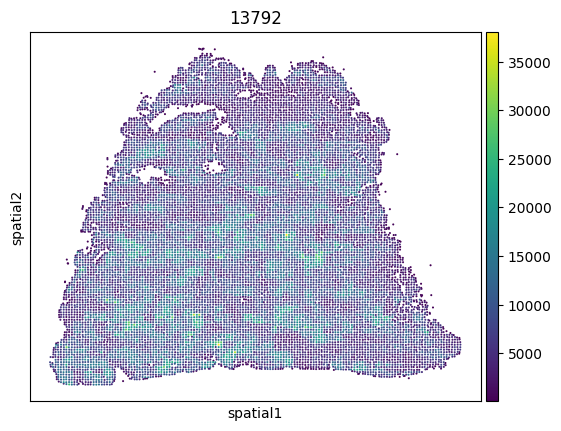

In [ ]:
combined_adata.obs["umi_count"] = combined_adata.X.sum(axis = 1)
sc.pl.embedding(combined_adata, basis = "spatial", color = "umi_count", title = combined_adata.shape)

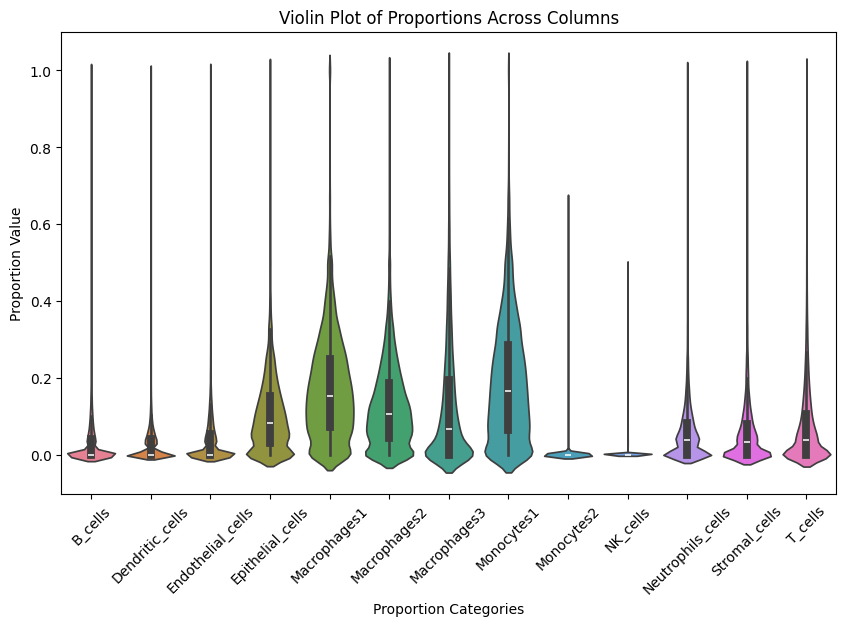

In [ ]:
dt = combined_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)
dt_ = dt_.sort_index(axis=1)

# Violin plot for more detailed distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(data=dt_)
plt.title('Violin Plot of Proportions Across Columns')
plt.ylabel('Proportion Value')
plt.xlabel('Proportion Categories')
plt.xticks(rotation=45) #after creating the plot. Here's how you can adjust the code:
plt.show()

In [ ]:
combined_adata.write_h5ad(binned_path)